# ONLINE NEWS POPULARITY PREDICTION

 ## PROBLEM STATEMENT
The rise of digital media has led to a massive influx of online news articles, but not all articles gain the same level of popularity.
Some go viral, while others struggle to attract readers. The challenge lies in understanding the key factors that contribute to an article’s success.
This project aims to build a predictive model that estimates the number of times an article will be shared based on various features, including textual
properties, social engagement metrics, and content attributes. By leveraging machine learning, we seek to provide insights into what makes an article 
widely shared.

## PROBLEM DESCRIPTION
Online news platforms generate a large volume of content daily, but only a fraction of articles achieve significant engagement.
Various factors, such as textual properties, publication time, and social media interactions, influence an article's popularity.
This project utilizes a dataset from the UCI Machine Learning Repository to analyze these factors and uncover patterns that contribute 
to higher shareability. By addressing challenges like feature selection, data skewness, and model optimization, we aim to develop a robust
predictive system for news article popularity.

## PROJECT OBJECTIVE
The objective of this project is to build a machine learning model that accurately predicts the number of times an article will be shared. 
This involves data preprocessing, feature selection, and training multiple regression models, including Linear Regression, Decision Tree, Random Forest,
Gradient Boosting, and Support Vector Regressor. The models will be evaluated using performance metrics like R-squared, Mean Absolute Error (MAE), 
and Mean Squared Error (MSE) to determine the most effective approach. Finally, the best-performing model will be fine-tuned and deployed to assist
content creators and publishers in optimizing their articles for greater audience engagement.

## DATASET INFORMATION
- *Source:* UCI Machine Learning Repository
- *Features:* The dataset consists of 17 columns, including numerical and categorical attributes such as article length, keyword frequency, and social shares.
- *Target Variable:* Popularity score of the article.(Shears)
- *type:* regression

## LOADING AND PREPROCESSING

##### Importing Necessary libraries

In [480]:
 import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew
from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

##### Load dataset

In [218]:
 dataset_url = (r"C:\Users\uw\Downloads\MAIN ONLINE NEWS POPULARITY.csv")
df = pd.read_csv(dataset_url)

##### Print initial dataset shape

In [221]:
 print("Dataset shape after loading:", df.shape)
print("Available columns:",df.columns)

Dataset shape after loading: (39644, 17)
Available columns: Index(['url', ' kw_avg_min', ' kw_avg_max', ' kw_max_avg',
       ' self_reference_min_shares', ' self_reference_max_shares',
       ' self_reference_avg_sharess', ' LDA_02', ' LDA_03',
       ' global_subjectivity', ' avg_negative_polarity',
       ' max_negative_polarity', ' title_subjectivity',
       ' title_sentiment_polarity', ' abs_title_subjectivity',
       ' abs_title_sentiment_polarity', ' shares'],
      dtype='object')


##### Remove unnecessary columns if present

In [224]:
 df = df.drop(columns=["unnecessary_column"], errors="ignore")

##### Handling missing values

In [228]:
# Print dataset shape
print("Dataset shape:",df.shape)

Dataset shape: (39644, 17)


In [230]:
# Check for missing values (count)
print("\nMissing values in each column:")
print(df.isnull().sum())


Missing values in each column:
url                              0
 kw_avg_min                      0
 kw_avg_max                      0
 kw_max_avg                      0
 self_reference_min_shares       0
 self_reference_max_shares       0
 self_reference_avg_sharess      0
 LDA_02                          0
 LDA_03                          0
 global_subjectivity             0
 avg_negative_polarity           0
 max_negative_polarity           0
 title_subjectivity              0
 title_sentiment_polarity        0
 abs_title_subjectivity          0
 abs_title_sentiment_polarity    0
 shares                          0
dtype: int64


In [232]:
# Check for missing values (percentage)
print("\nPercentage of missing values in each column:")
print((df.isnull().sum()/len(df))*100)


Percentage of missing values in each column:
url                              0.0
 kw_avg_min                      0.0
 kw_avg_max                      0.0
 kw_max_avg                      0.0
 self_reference_min_shares       0.0
 self_reference_max_shares       0.0
 self_reference_avg_sharess      0.0
 LDA_02                          0.0
 LDA_03                          0.0
 global_subjectivity             0.0
 avg_negative_polarity           0.0
 max_negative_polarity           0.0
 title_subjectivity              0.0
 title_sentiment_polarity        0.0
 abs_title_subjectivity          0.0
 abs_title_sentiment_polarity    0.0
 shares                          0.0
dtype: float64


In [233]:
# Filter columns with missing values only
missing = df.isnull().sum()
missing = missing[missing > 0]
print("\nColumns with missing values:")
print(missing)


Columns with missing values:
Series([], dtype: int64)


In [237]:
 df = df.dropna()

##### Remove non-numeric characters from column names

In [240]:
 df.columns = df.columns.str.replace(r'\xa0', '', regex=True).str.strip()

In [243]:
# Set style
sns.set(style='whitegrid')

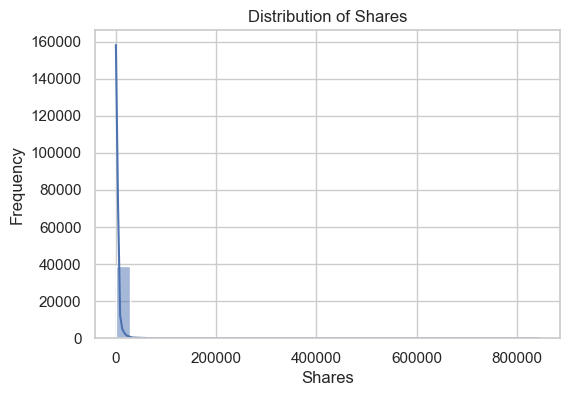

In [245]:
plt.figure(figsize=(6, 4))
sns.histplot(df['shares'], kde=True, bins=30)
plt.title('Distribution of Shares')
plt.xlabel('Shares')
plt.ylabel('Frequency')
plt.show()

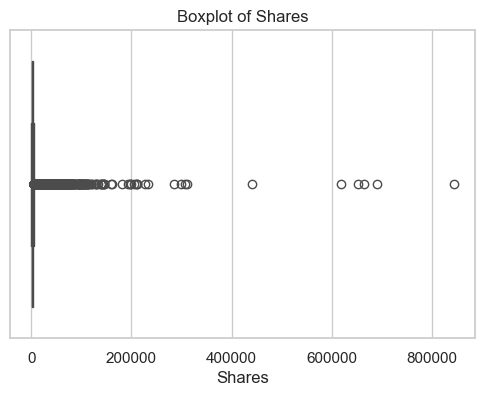

In [246]:
plt.figure(figsize=(6, 4))
sns.boxplot(x=df['shares'])
plt.title('Boxplot of Shares')
plt.xlabel('Shares')
plt.show()

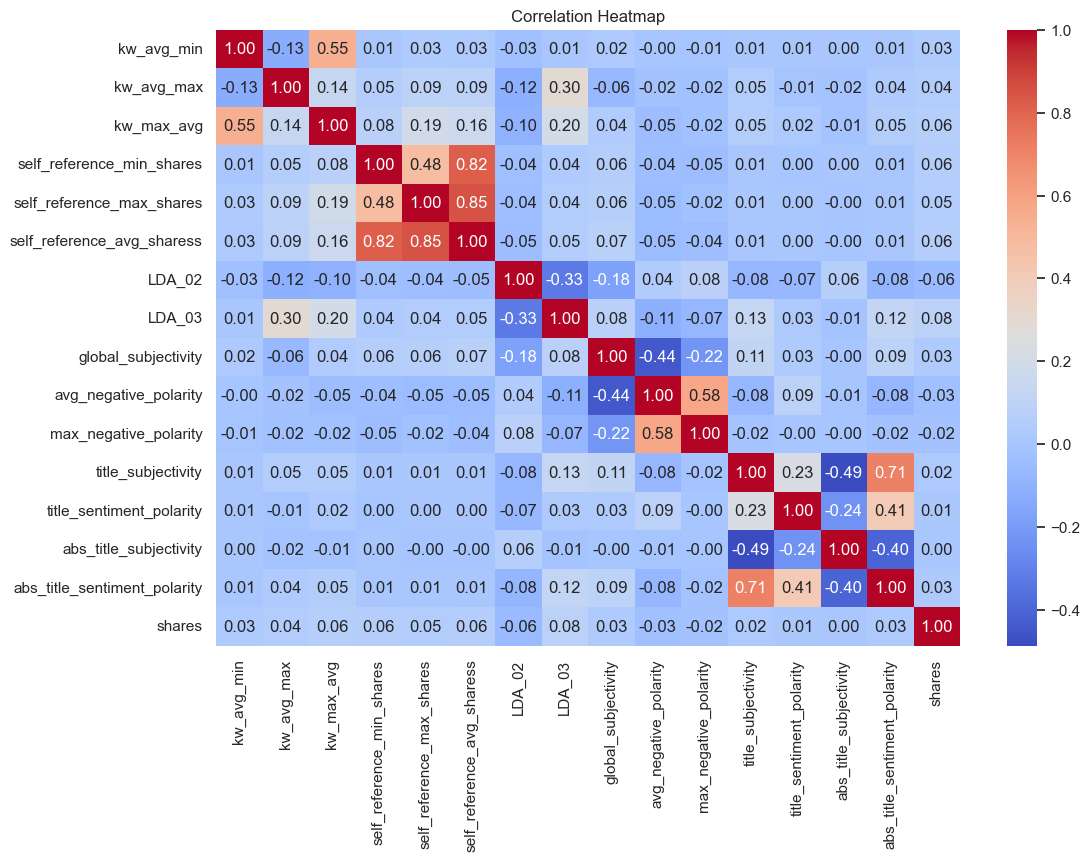

In [247]:
# Select only numeric columns before computing correlation
numeric_df = df.select_dtypes(include='number')

# Now compute correlation and plot heatmap
plt.figure(figsize=(12, 8))
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

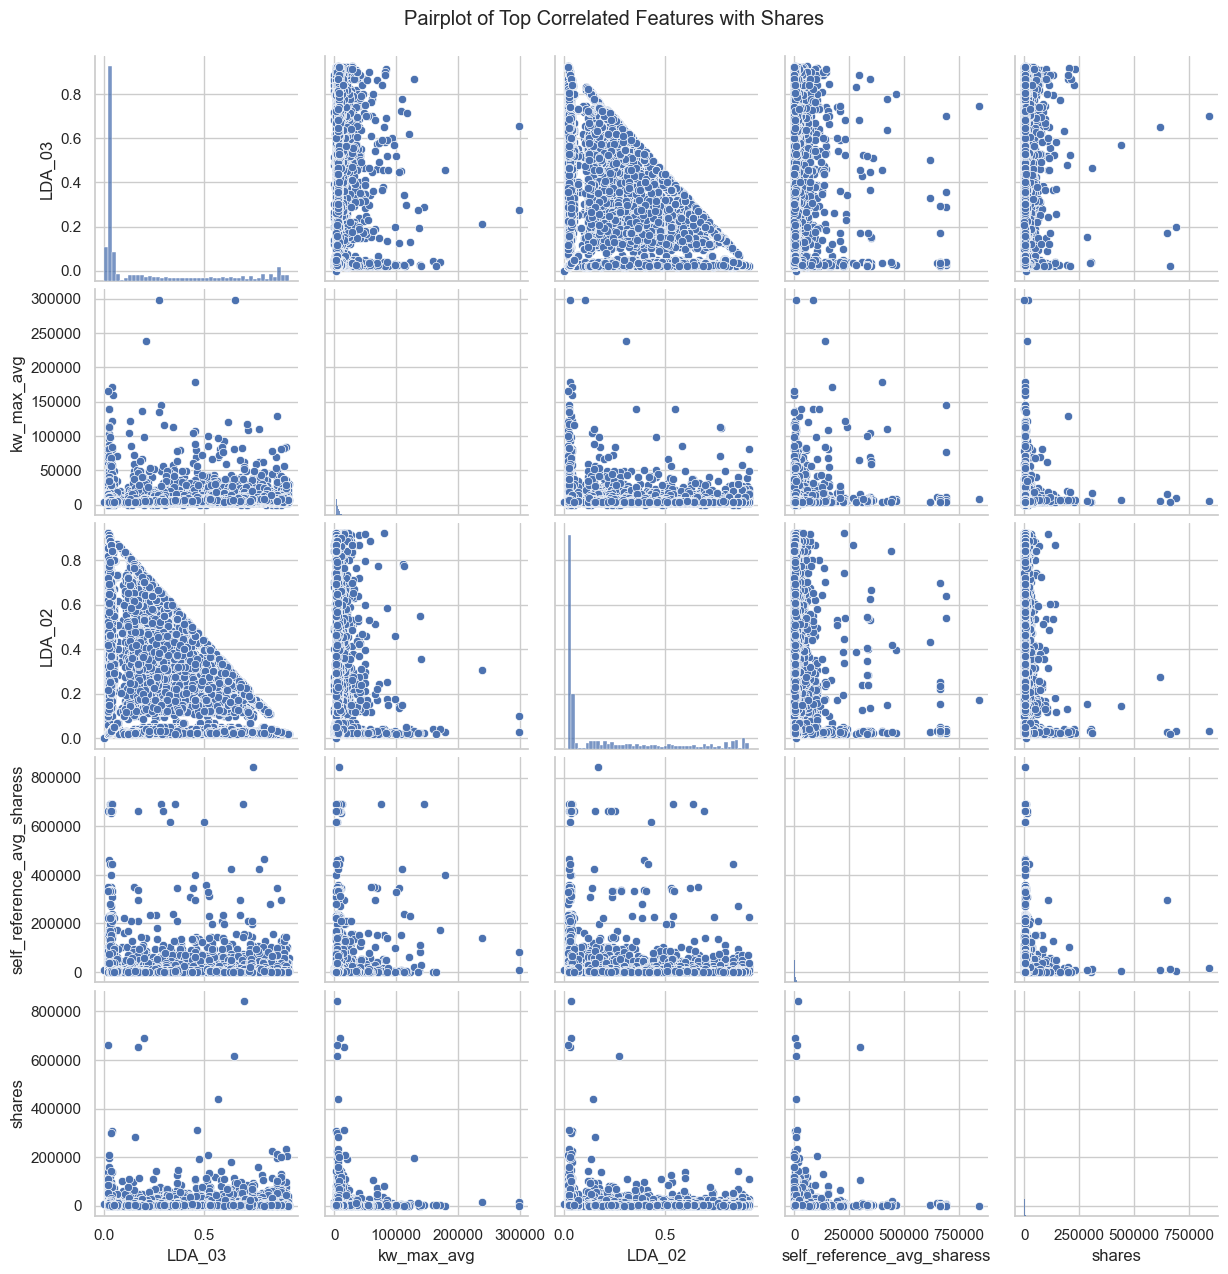

In [248]:
top_corr = corr['shares'].abs().sort_values(ascending=False)[1:5].index  # top 4 correlated
sns.pairplot(df[list(top_corr) + ['shares']])
plt.suptitle('Pairplot of Top Correlated Features with Shares', y=1.02)
plt.show()

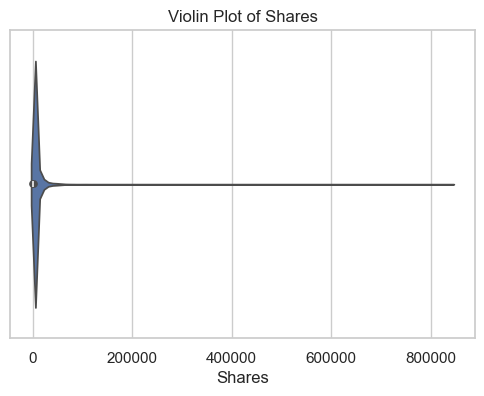

In [249]:
plt.figure(figsize=(6, 4))
sns.violinplot(x=df['shares'])
plt.title('Violin Plot of Shares')
plt.xlabel('Shares')
plt.show()

##### FEATURE SELECTION
##### Feature Selection - Removing highly correlated features 

In [260]:
 def univariate_analysis(data):
    for col in data.select_dtypes(include=['int64', 'float64']).columns:
        plt.figure(figsize=(8, 4))
        sns.histplot(data[col], kde=True, bins=30)
        plt.title(f'Univariate Analysis: {col}')
        plt.show()  

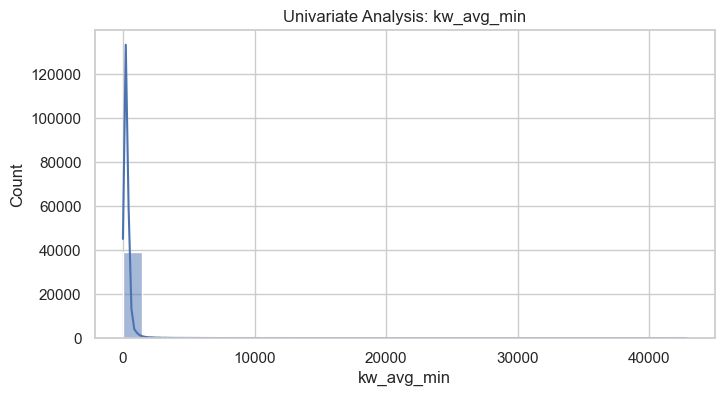

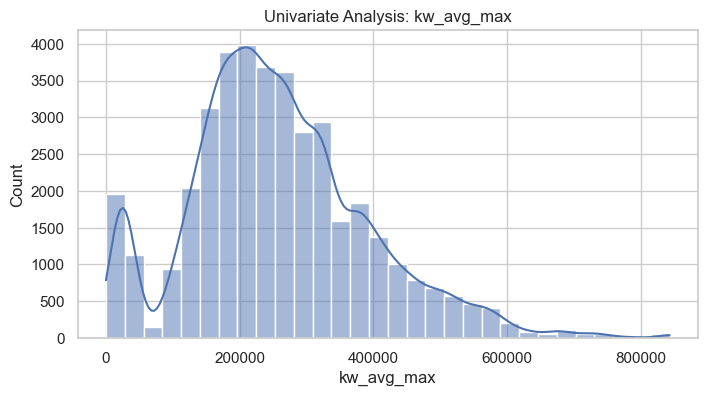

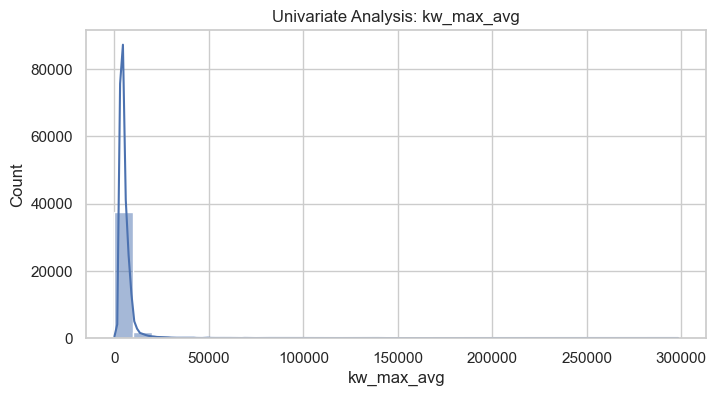

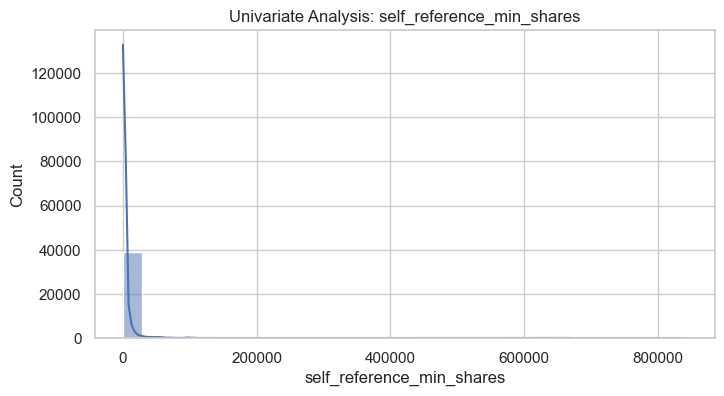

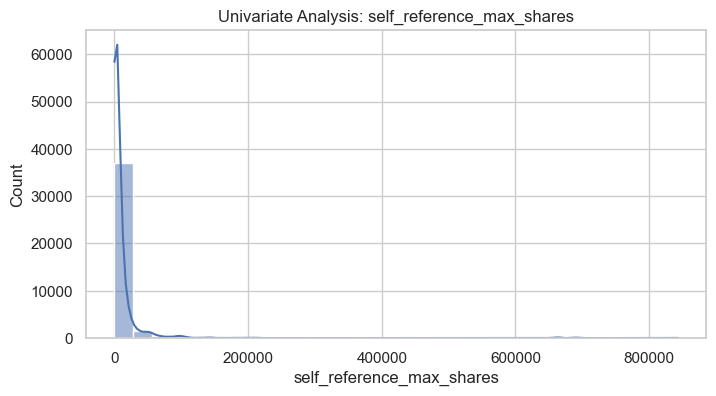

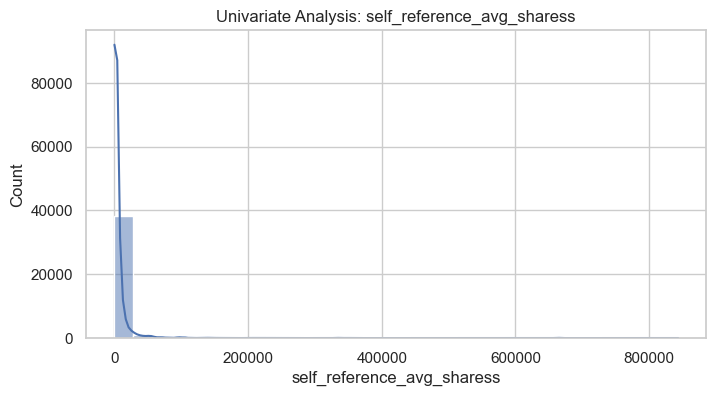

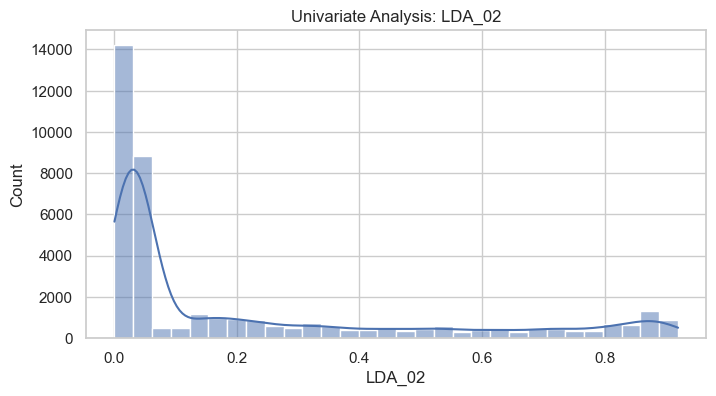

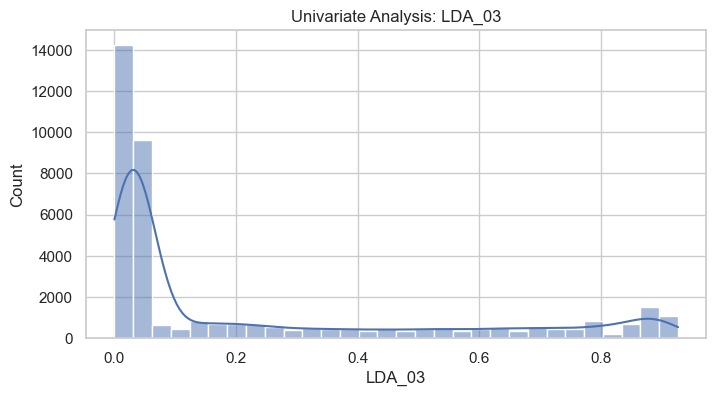

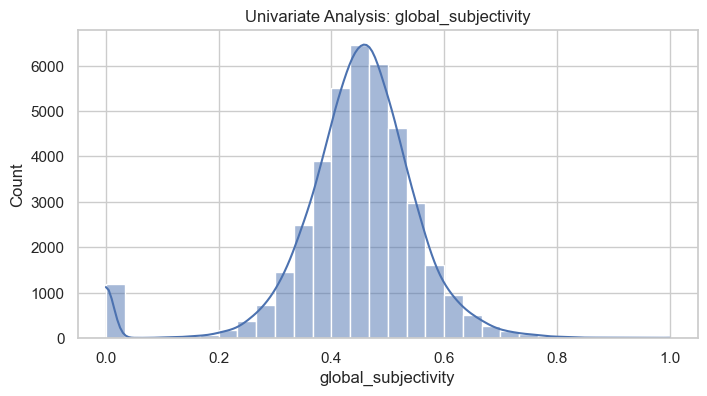

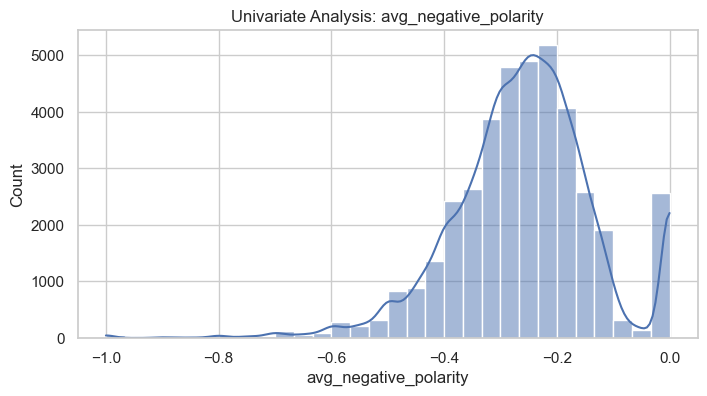

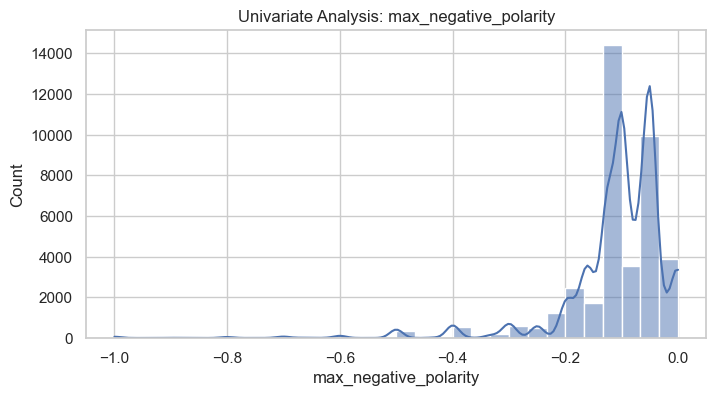

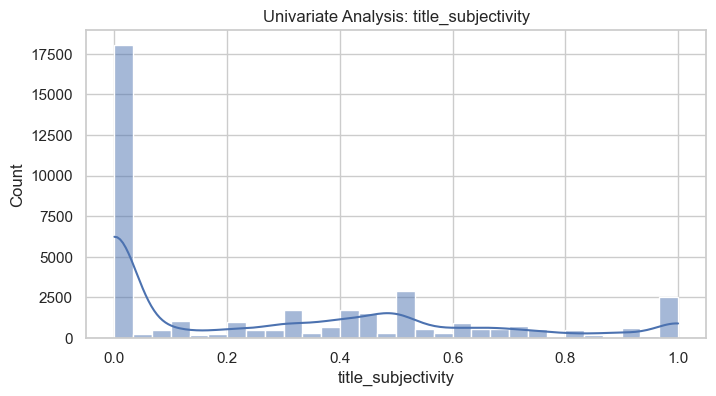

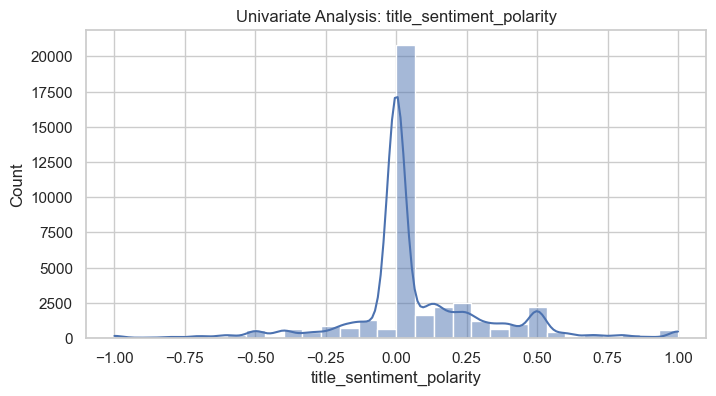

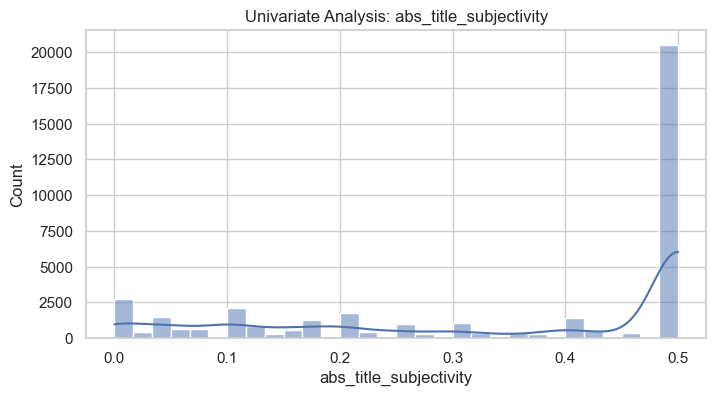

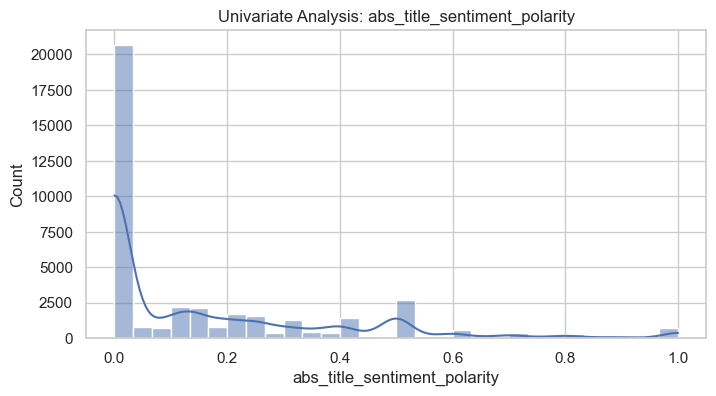

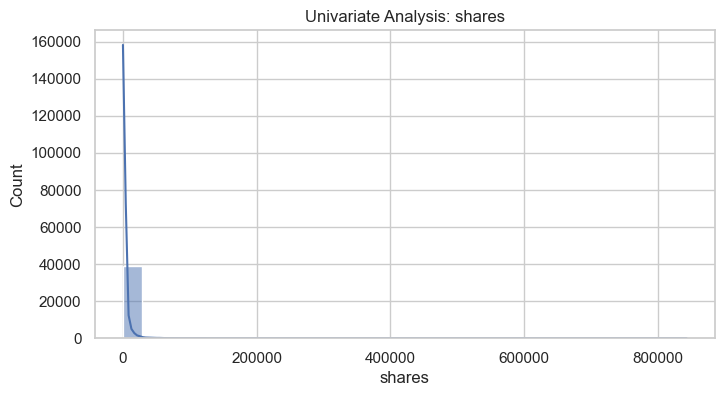

In [262]:
# Perform Univariate Analysis
univariate_analysis(df)

In [263]:
# Bivariate Analysis
def bivariate_analysis(data):
 sns.pairplot(data, diag_kind='kde')
plt.show()

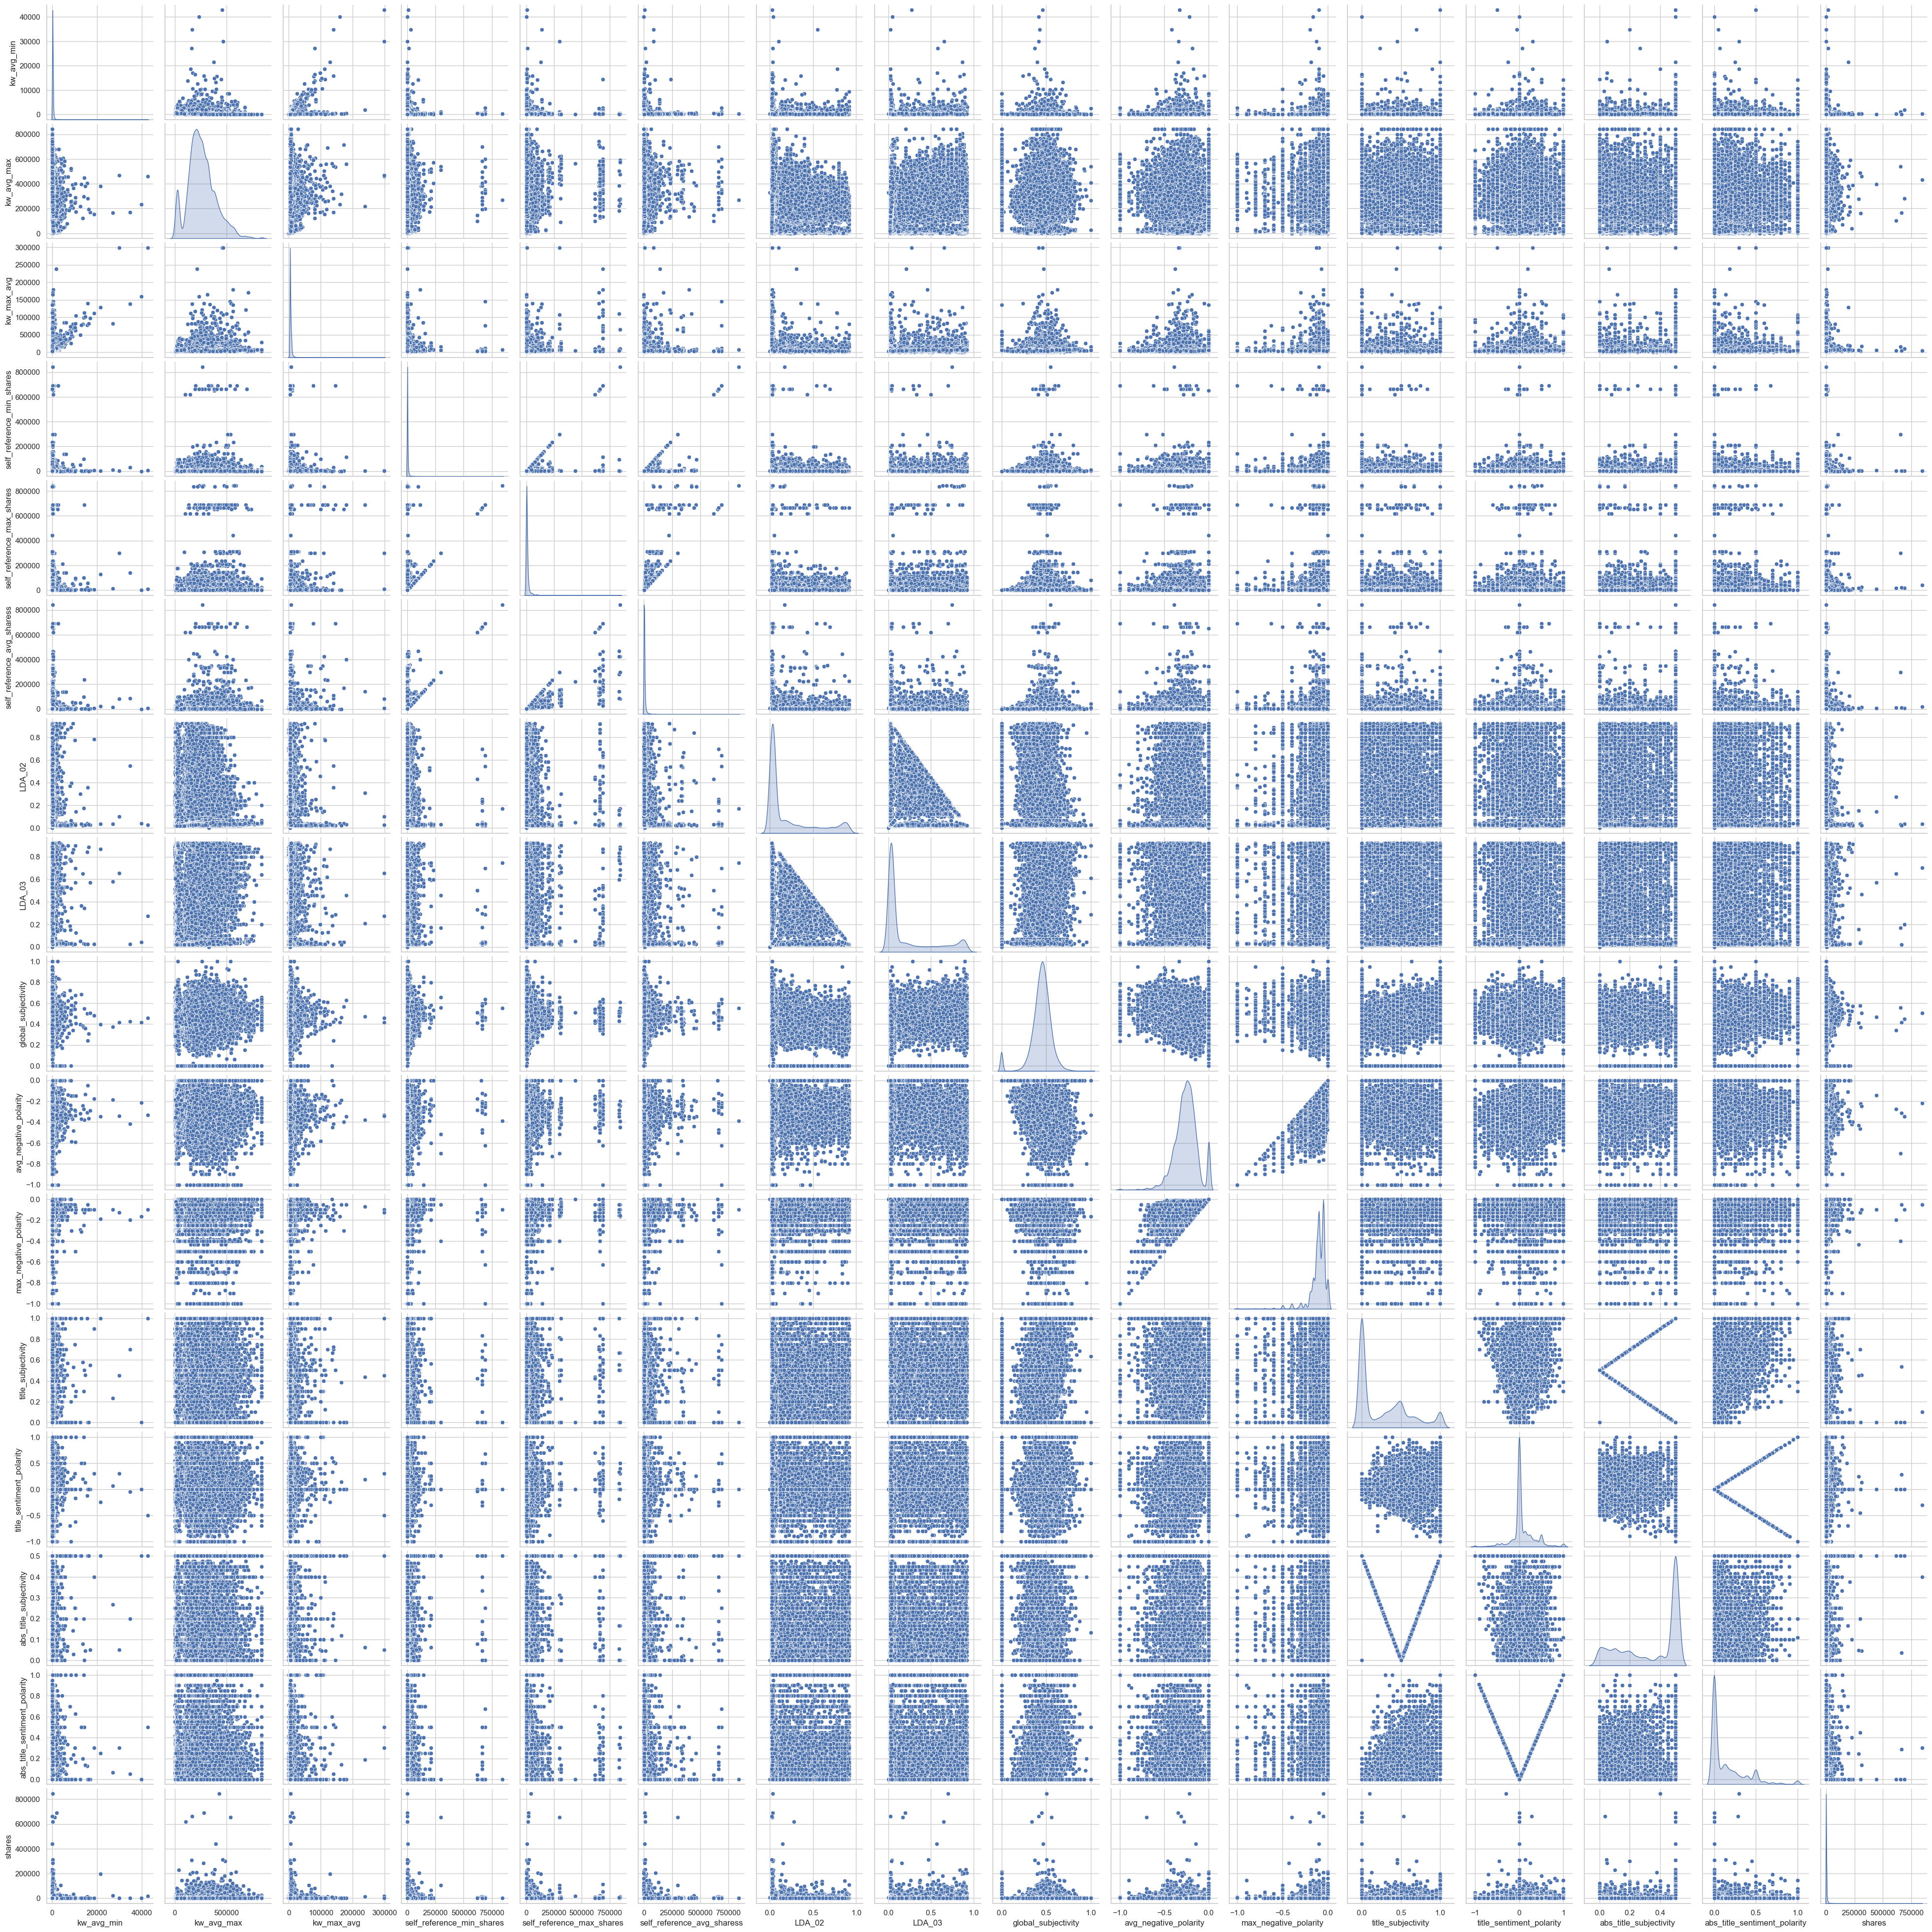

In [264]:
#Perform Bivariate Analysis
bivariate_analysis(df)

In [265]:
#Feature Selection - Removing highly correlated features
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
correlation_matrix = df[numeric_cols].corr()

##### Identify and remove highly correlated features

In [267]:
#Identify and remove highly correlated features
threshold = 0.85
corr_features = set()
for col in correlation_matrix.columns:
    high_corr = correlation_matrix[col][correlation_matrix[col] > threshold].index.tolist()
    high_corr.remove(col) if col in high_corr else None
    corr_features.update(high_corr)

print("Highly Correlated Features to Remove:", corr_features)
df_filtered = df.drop(columns=corr_features)

Highly Correlated Features to Remove: {'self_reference_avg_sharess', 'self_reference_max_shares'}


In [268]:
print("Numeric columns in df_filtered:", df_filtered.columns)
print("Expected numeric columns:",numeric_cols)

Numeric columns in df_filtered: Index(['url', 'kw_avg_min', 'kw_avg_max', 'kw_max_avg',
       'self_reference_min_shares', 'LDA_02', 'LDA_03', 'global_subjectivity',
       'avg_negative_polarity', 'max_negative_polarity', 'title_subjectivity',
       'title_sentiment_polarity', 'abs_title_subjectivity',
       'abs_title_sentiment_polarity', 'shares'],
      dtype='object')
Expected numeric columns: Index(['kw_avg_min', 'kw_avg_max', 'kw_max_avg', 'self_reference_min_shares',
       'self_reference_max_shares', 'self_reference_avg_sharess', 'LDA_02',
       'LDA_03', 'global_subjectivity', 'avg_negative_polarity',
       'max_negative_polarity', 'title_subjectivity',
       'title_sentiment_polarity', 'abs_title_subjectivity',
       'abs_title_sentiment_polarity', 'shares'],
      dtype='object')


In [269]:
numeric_cols = [col for col in numeric_cols if col in df_filtered.columns]

In [270]:
numeric_cols = df_filtered.select_dtypes(include=['int64', 'float64']).columns.tolist()

##### HANDLING SKEWNESS

In [278]:
#Handling Skewness
skewed_features = df_filtered[numeric_cols].apply(lambda x: skew(x.dropna())).sort_values(ascending=False)
print("Skewness of numeric features:\n", skewed_features)

Skewness of numeric features:
 shares                          33.962600
kw_avg_min                      31.304924
self_reference_min_shares       26.263370
kw_max_avg                      16.411049
abs_title_sentiment_polarity     1.704129
LDA_02                           1.311645
LDA_03                           1.238669
title_subjectivity               0.816054
kw_avg_max                       0.624286
title_sentiment_polarity         0.396094
avg_negative_polarity           -0.551623
abs_title_subjectivity          -0.624126
global_subjectivity             -1.372637
max_negative_polarity           -3.459616
dtype: float64


In [281]:
# Select numerical columns only
numerical_cols = df.select_dtypes(include='number')

In [290]:
# Calculate skewness
skewness = numerical_cols.skew()

In [292]:
# Identify features with high skewness (absolute value > 1)
skewed_features = skewness[abs(skewness)>1].index

In [294]:
# Apply log1p (log(1 + x)) to handle skewness safely
#df[skewed_features] = df[skewed_features].apply(lambda x: np.log1p(x))
print("Applied log transformation to skewed features:")
print(skewed_features)

Applied log transformation to skewed features:
Index(['kw_avg_min', 'kw_max_avg', 'self_reference_min_shares',
       'self_reference_max_shares', 'self_reference_avg_sharess', 'LDA_02',
       'LDA_03', 'global_subjectivity', 'max_negative_polarity',
       'abs_title_sentiment_polarity', 'shares'],
      dtype='object')


##### DEFINE TARGET AND FEATURES

In [300]:
 X = df_filtered.drop(columns=['shares'])  # Features
y = df_filtered['shares']  # Target variable

##### Split into training and test sets

In [303]:
 X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train Shape:", X_train.shape, "Test Shape:",X_test.shape)

Train Shape: (31715, 14) Test Shape: (7929, 14)


In [305]:
print("X_train shape:",X_train.shape)
print("X_test shape:",X_test.shape)

X_train shape: (31715, 14)
X_test shape: (7929, 14)


In [307]:
print(type(X_train))
print(type(X_test))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>


In [309]:
if isinstance(X_train, pd.Series):
    X_train = X_train.to_frame()

if isinstance(X_test, pd.Series):
    X_test = X_test.to_frame()

In [311]:
print(X_train.isnull().sum().sum())  # Count total missing values
print(X_train.dtypes)  # Ensure all columns are numeric

0
url                              object
kw_avg_min                      float64
kw_avg_max                      float64
kw_max_avg                      float64
self_reference_min_shares       float64
LDA_02                          float64
LDA_03                          float64
global_subjectivity             float64
avg_negative_polarity           float64
max_negative_polarity           float64
title_subjectivity              float64
title_sentiment_polarity        float64
abs_title_subjectivity          float64
abs_title_sentiment_polarity    float64
dtype: object


In [314]:
# Drop the 'url' column
df.drop('url', axis=1, inplace=True)

In [316]:
# Optional: Check if it's removed
print("Updated columns:")
print(df.columns)

Updated columns:
Index(['kw_avg_min', 'kw_avg_max', 'kw_max_avg', 'self_reference_min_shares',
       'self_reference_max_shares', 'self_reference_avg_sharess', 'LDA_02',
       'LDA_03', 'global_subjectivity', 'avg_negative_polarity',
       'max_negative_polarity', 'title_subjectivity',
       'title_sentiment_polarity', 'abs_title_subjectivity',
       'abs_title_sentiment_polarity', 'shares'],
      dtype='object')


In [319]:
print("X_train columns:",X_train.columns)
print("X_test columns:",X_test.columns)

X_train columns: Index(['url', 'kw_avg_min', 'kw_avg_max', 'kw_max_avg',
       'self_reference_min_shares', 'LDA_02', 'LDA_03', 'global_subjectivity',
       'avg_negative_polarity', 'max_negative_polarity', 'title_subjectivity',
       'title_sentiment_polarity', 'abs_title_subjectivity',
       'abs_title_sentiment_polarity'],
      dtype='object')
X_test columns: Index(['url', 'kw_avg_min', 'kw_avg_max', 'kw_max_avg',
       'self_reference_min_shares', 'LDA_02', 'LDA_03', 'global_subjectivity',
       'avg_negative_polarity', 'max_negative_polarity', 'title_subjectivity',
       'title_sentiment_polarity', 'abs_title_subjectivity',
       'abs_title_sentiment_polarity'],
      dtype='object')


In [321]:
#from sklearn.preprocessing import StandardScaler

##### Ensure only numeric columns are selected

In [324]:
 numeric_cols = X_train.select_dtypes(include=['number']).columns

##### INITIALIZE STANDARDSCALER

In [327]:
 scaler = StandardScaler()

##### Apply Standardization

In [330]:
 X_train_scaled = X_train.copy()
X_test_scaled=X_test.copy()

In [332]:
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

##### Check results

In [335]:
 print(X_train_scaled.head())
print(X_test_scaled.head())

                                                     url  kw_avg_min  \
19837  http://mashable.com/2014/02/04/apple-iphone-st...   -0.023319   
904    http://mashable.com/2013/01/23/bloomberg-billi...    0.220739   
23876  http://mashable.com/2014/04/21/marvel-universe...   -0.328830   
22966  http://mashable.com/2014/04/04/elder-scrolls-o...   -0.176412   
4705     http://mashable.com/2013/04/01/the-freedom-bay/    0.692773   

       kw_avg_max  kw_max_avg  self_reference_min_shares    LDA_02    LDA_03  \
19837    0.555255    0.102276                  -0.173842 -0.662564  0.744177   
904     -1.735538   -0.464187                  -0.215315  2.063828 -0.588251   
23876    0.597691   -0.252056                   0.195479  1.345297  0.199820   
22966    0.604236   -0.017087                  -0.215315 -0.663381 -0.660804   
4705    -0.641535   -0.365069                  -0.215315 -0.587622 -0.588174   

       global_subjectivity  avg_negative_polarity  max_negative_polarity  \
19837     

##### HYPERPARAMETER TUNING
##### Hyperparameter Tuning with RandomizedSearchCV

In [338]:
 rf = RandomForestRegressor()
param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 20, None],
    "min_samples_split":[2, 5, 10],
    "min_samples_leaf":[1,2,4]
}

##### Initialize RandomizedSearchCV

In [346]:
#Initialize RandomizedSearchCV
rf_random = RandomizedSearchCV(
    estimator=rf, 
    param_distributions=param_dist, 
    n_iter=10,  # Number of random samples to test
    cv=5,       # 5-fold cross-validation
    verbose=2,  # Show progress
    random_state=42, 
    n_jobs=-1   # Use all available CPUs
)

In [478]:
print(X_train_scaled.dtypes)

url                             float64
kw_avg_min                      float64
kw_avg_max                      float64
kw_max_avg                      float64
self_reference_min_shares       float64
LDA_02                          float64
LDA_03                          float64
global_subjectivity             float64
avg_negative_polarity           float64
max_negative_polarity           float64
title_subjectivity              float64
title_sentiment_polarity        float64
abs_title_subjectivity          float64
abs_title_sentiment_polarity    float64
dtype: object


In [350]:
print(X_train_scaled.shape, y_train.shape)

(31715, 14) (31715,)


In [352]:
print(rf.get_params().keys())

dict_keys(['bootstrap', 'ccp_alpha', 'criterion', 'max_depth', 'max_features', 'max_leaf_nodes', 'max_samples', 'min_impurity_decrease', 'min_samples_leaf', 'min_samples_split', 'min_weight_fraction_leaf', 'monotonic_cst', 'n_estimators', 'n_jobs', 'oob_score', 'random_state', 'verbose', 'warm_start'])


In [354]:
print(param_dist)  # Ensure valid parameter ranges

{'n_estimators': [100, 200, 300], 'max_depth': [10, 20, None], 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4]}


In [356]:
print(X_train_scaled.shape, y_train.shape)  
print(type(X_train_scaled),type(y_train))

(31715, 14) (31715,)
<class 'pandas.core.frame.DataFrame'> <class 'pandas.core.series.Series'>


In [358]:
import json
print(json.dumps(param_dist, indent=4))  # Ensure no invalid values

{
    "n_estimators": [
        100,
        200,
        300
    ],
    "max_depth": [
        10,
        20,
        null
    ],
    "min_samples_split": [
        2,
        5,
        10
    ],
    "min_samples_leaf": [
        1,
        2,
        4
    ]
}


In [360]:
print(X_train_scaled.info())  # Data types & missing values
print(y_train.isnull().sum())  # Missing values in target

<class 'pandas.core.frame.DataFrame'>
Index: 31715 entries, 19837 to 15795
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   url                           31715 non-null  object 
 1   kw_avg_min                    31715 non-null  float64
 2   kw_avg_max                    31715 non-null  float64
 3   kw_max_avg                    31715 non-null  float64
 4   self_reference_min_shares     31715 non-null  float64
 5   LDA_02                        31715 non-null  float64
 6   LDA_03                        31715 non-null  float64
 7   global_subjectivity           31715 non-null  float64
 8   avg_negative_polarity         31715 non-null  float64
 9   max_negative_polarity         31715 non-null  float64
 10  title_subjectivity            31715 non-null  float64
 11  title_sentiment_polarity      31715 non-null  float64
 12  abs_title_subjectivity        31715 non-null  float64
 13  ab

In [362]:
print(X_train_scaled.dtypes)  # Check data types
print(y_train.dtypes)  # Check if y_train is numeric

url                              object
kw_avg_min                      float64
kw_avg_max                      float64
kw_max_avg                      float64
self_reference_min_shares       float64
LDA_02                          float64
LDA_03                          float64
global_subjectivity             float64
avg_negative_polarity           float64
max_negative_polarity           float64
title_subjectivity              float64
title_sentiment_polarity        float64
abs_title_subjectivity          float64
abs_title_sentiment_polarity    float64
dtype: object
int64


In [364]:
X_train_scaled = X_train_scaled.apply(pd.to_numeric, errors='coerce')
y_train = pd.to_numeric(y_train, errors='coerce')

In [366]:
X_train_scaled = X_train_scaled.fillna(X_train_scaled.mean(numeric_only=True))
y_train = y_train.fillna(y_train.mean())

In [368]:
print(hasattr(rf_random, "best_estimator_"))  # Should return True

False


In [370]:
print(X_train.shape, y_train.shape)

(31715, 14) (31715,)


In [372]:
y_train = y_train.values.ravel()

In [374]:
#print(X_train.dtypes)
#print(y_train.dtype)

In [376]:
X_train = X_train.apply(pd.to_numeric, errors='coerce')
y_train = pd.to_numeric(y_train, errors='coerce')

In [378]:
import pandas as pd

X_train = pd.DataFrame(X_train)  # Convert back to DataFrame
y_train = pd.Series(y_train)  # Convert back to Series

X_train = X_train.fillna(X_train.mean())
y_train = y_train.fillna(y_train.mean())

##### Ensure rf_random is fitted before accessing best_estimator_
##### Now best_estimator_ should exist

In [381]:
# Ensure rf_random is fitted before accessing best_estimator_
if not hasattr(rf_random, "best_estimator_"):
    rf_random.fit(X_train_scaled, y_train)

# Now best_estimator_ should exist
best_rf = rf_random.best_estimator_
best_rf.fit(X_train_scaled, y_train)  # Fit the best model if needed



Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomForestRegressor(max_depth=10, min_samples_leaf=4)

In [382]:
#Best Model Selection
#best_rf = rf_random.best_estimator_
#best_rf.fit(X_train_scaled,y_train)

In [383]:
print(hasattr(best_rf,"fit"))
print(hasattr(best_rf,"predict"))

True
True


In [384]:
print(hasattr(best_rf, "n_estimators"))  

True


In [385]:
print(X_test_scaled.shape)  
print(type(X_test_scaled))  
print(X_test_scaled.isnull().sum().sum())

(7929, 14)
<class 'pandas.core.frame.DataFrame'>
0


In [391]:
print(X_test_scaled.dtypes)
print(X_test_scaled.select_dtypes(exclude=['number']).head())

url                              object
kw_avg_min                      float64
kw_avg_max                      float64
kw_max_avg                      float64
self_reference_min_shares       float64
LDA_02                          float64
LDA_03                          float64
global_subjectivity             float64
avg_negative_polarity           float64
max_negative_polarity           float64
title_subjectivity              float64
title_sentiment_polarity        float64
abs_title_subjectivity          float64
abs_title_sentiment_polarity    float64
dtype: object
                                                     url
32340  http://mashable.com/2014/09/08/safest-cabbies-...
10480   http://mashable.com/2013/07/25/3d-printed-rifle/
15370  http://mashable.com/2013/10/30/digital-dinosau...
31592  http://mashable.com/2014/08/27/homer-simpson-i...
198    http://mashable.com/2013/01/10/creepy-robotic-...


In [393]:
print(X_test_scaled.isnull().sum())

url                             0
kw_avg_min                      0
kw_avg_max                      0
kw_max_avg                      0
self_reference_min_shares       0
LDA_02                          0
LDA_03                          0
global_subjectivity             0
avg_negative_polarity           0
max_negative_polarity           0
title_subjectivity              0
title_sentiment_polarity        0
abs_title_subjectivity          0
abs_title_sentiment_polarity    0
dtype: int64


In [395]:
X_test_scaled = X_test_scaled.fillna(0)  # Or use mean, median, etc.

In [397]:
print(set(X_train_scaled.columns) - set(X_test_scaled.columns))
print(set(X_test_scaled.columns) - set(X_train_scaled.columns))

set()
set()


In [399]:
from sklearn.utils.validation import check_is_fitted

try:
    check_is_fitted(best_rf)
    print("Model is fitted and ready to predict.")
except:
    print("Error: Model is not trained. Fit it before predicting.")

Model is fitted and ready to predict.


In [401]:
print("Train shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)

Train shape: (31715, 14)
Test shape: (7929, 14)


In [403]:
print(X_test_scaled.dtypes)

url                              object
kw_avg_min                      float64
kw_avg_max                      float64
kw_max_avg                      float64
self_reference_min_shares       float64
LDA_02                          float64
LDA_03                          float64
global_subjectivity             float64
avg_negative_polarity           float64
max_negative_polarity           float64
title_subjectivity              float64
title_sentiment_polarity        float64
abs_title_subjectivity          float64
abs_title_sentiment_polarity    float64
dtype: object


In [405]:
X_test_scaled = X_test_scaled.apply(pd.to_numeric, errors='coerce')  # Convert all to numeric

In [407]:
import numpy as np

X_test_array = X_test_scaled.to_numpy()  # Convert to NumPy array

print("Missing values in X_test_scaled:", np.isnan(X_test_array).sum())
print("Infinite values in X_test_scaled:", np.isinf(X_test_array).sum())

Missing values in X_test_scaled: 7929
Infinite values in X_test_scaled: 0


##### MODEL EVALUATION

In [431]:
#Check data
print("X_train shape:",X_train.shape)
print("y_train shape:",y_train.shape)

X_train shape: (31715, 14)
y_train shape: (31715,)


In [449]:
# Initialize models
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "Gradient Boosting": GradientBoostingRegressor(),
    "Support Vector Regressor":SVR()
}

In [457]:
print(X_train_scaled.isnull().sum())  # For DataFrame
print(pd.isnull(y_train).sum())

url                             31715
kw_avg_min                          0
kw_avg_max                          0
kw_max_avg                          0
self_reference_min_shares           0
LDA_02                              0
LDA_03                              0
global_subjectivity                 0
avg_negative_polarity               0
max_negative_polarity               0
title_subjectivity                  0
title_sentiment_polarity            0
abs_title_subjectivity              0
abs_title_sentiment_polarity        0
dtype: int64
0


In [459]:
# Fill missing values with median (or you can use mean)
X_train_scaled = pd.DataFrame(X_train_scaled).fillna(np.nanmedian(X_train_scaled))
y_train = pd.Series(y_train).fillna(np.nanmedian(y_train))

In [461]:
X_train_scaled = pd.DataFrame(X_train_scaled).apply(pd.to_numeric, errors='coerce')
y_train = pd.to_numeric(y_train, errors='coerce')

In [463]:
# Train all models
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    print(f"{name} trained successfully.")

Linear Regression trained successfully.
Decision Tree trained successfully.
Random Forest trained successfully.
Gradient Boosting trained successfully.
Support Vector Regressor trained successfully.


In [469]:
# Save Model & Scaler
joblib.dump(best_rf, "best_random_forest_model.pkl")
joblib.dump(scaler,"scaler.pkl")

['scaler.pkl']

##### Save Model & Scaler

In [472]:
# Load Model & Scaler for Prediction
loaded_model = joblib.load("best_random_forest_model.pkl")
loaded_scaler = joblib.load("scaler.pkl")

In [474]:
print(X_test.shape)
print(X_test.iloc[:5].shape)
print(loaded_scaler.mean_)  

(7929, 14)
(5, 14)
[ 3.16062163e+02  2.59157530e+05  5.68105250e+03  3.82625451e+03
  2.15889012e-01  2.23273379e-01  4.43339857e-01 -2.59475104e-01
 -1.07433378e-01  2.82672312e-01  7.10994724e-02  3.41869626e-01
  1.56645468e-01]


## TESTING WITH UNSEENED DATA

In [157]:
# Correct way to load an Excel file
df = pd.read_excel(r"C:\Users\uw\Downloads\online_news_popularity.xlsx")

In [163]:
# Split features and target
X=df.drop(columns='shares')
y=df['shares']

In [165]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [167]:
# . Define which columns are numeric vs. categorical
numeric_features   = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

In [179]:
# Numeric and categorical pipelines
numeric_transformer = Pipeline([
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Column transformer
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

In [181]:
# . Assemble full pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

In [185]:
# . Fit on your training data
pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['word_count', 'num_links',
                                                   'sentiment_score']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['title', 'category'])])),
                ('model', RandomForestRegressor(random_state=42))])

In [189]:
# . (Optional) Evaluate quickly
print("Validation R²:", pipeline.score(X_val,y_val))

Validation R²: -0.9779877813504823


In [191]:
# . Save the pipeline for later use
joblib.dump(pipeline, '/mnt/data/final_pipeline.pkl')
print("Pipeline saved to final_pipeline.pkl")

Pipeline saved to final_pipeline.pkl


In [195]:
# . Load your saved pipeline
pipeline = joblib.load('/mnt/data/final_pipeline.pkl')

In [197]:
# . Read in the unseen dataset
df_unseen = pd.read_excel(r"C:\Users\uw\Downloads\online_news_popularity.xlsx")  # replace with your path

In [199]:
# . Drop target if accidentally present
df_unseen = df_unseen.drop(columns=['shares'], errors='ignore')

In [201]:
# . Predict in one line—pipeline does all preprocessing under the hood
preds = pipeline.predict(df_unseen)

In [205]:
# . Pack into a DataFrame and print
pred_df = pd.DataFrame({'predicted_shares': preds})
print("Predicted Shares:\n",pred_df)

Predicted Shares:
     predicted_shares
0             2259.0
1             4836.0
2             3245.0
3             2776.0
4             4482.0
5             4613.0
6             3281.0
7             2482.0
8             3823.0
9             4276.0
10            4778.0
11            3583.0
12            3206.0
13            3778.0
14            3317.0
15            4383.0
16            3551.0
17            4528.0
18            3221.0
19            4072.0
20            3007.0
21            3274.0
22            3990.0
23            3713.0
24            4922.0
25            3993.0
26            4434.0
27            3991.0
28            3657.0
29            4585.0


In [207]:
# . Save to CSV
pred_df.to_csv('/mnt/data/pipeline_predictions.csv', index=False)
print("Saved predictions to pipeline_predictions.csv")

Saved predictions to pipeline_predictions.csv


## CONCLUSION
This project successfully predicted online news article popularity based on various features. 
After testing multiple regression models, the best-performing model was selected using MAE, MSE, and R² Score. 
The final model showed good generalization on unseen data, providing useful insights for content optimization.

## FUTURE WORK
. Real-Time Data: Integrate live article performance for better accuracy.
. Feature Improvement: Add sentiment analysis and trending topics.
. Advanced Models: Explore deep learning techniques.
. User Behavior: Include engagement metrics like time spent on articles.
. Deployment: Develop a web tool or API for real-time predictions.